In [ ]:

# COMS3007A  Assignment 2:


##  Cell 0 — Install Dependencies


In [1]:
!pip install lightgbm pyarrow fastparquet scikit-learn pandas numpy scipy tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.9 MB/s eta 0:00:00


##  Cell 1 — Imports

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import lightgbm as lgb
from tqdm import tqdm
import warnings, os, pickle

warnings.filterwarnings('ignore')
np.random.seed(42)

#Exact schema constants
SAMPLE_COL  = 'Sample_ID'
TIME_COL    = 'Time_Step'
LABEL_COL   = 'class_label'
PRED_COL    = 'Predicted_Class'
SIGNAL_COLS = [f'Signal_{c}' for c in 'ABCDEFGHIJKLMN']  # Signal_A … Signal_N
N_CLASSES   = 6

print("Imports OK.")
print(f"Signal columns: {SIGNAL_COLS}")

Imports OK.
Signal columns: ['Signal_A', 'Signal_B', 'Signal_C', 'Signal_D', 'Signal_E', 'Signal_F', 'Signal_G', 'Signal_H', 'Signal_I', 'Signal_J', 'Signal_K', 'Signal_L', 'Signal_M', 'Signal_N']


## Cell 2 — Data Loading



In [ ]:
import sys

def _get_data_dir() -> str:
    """
    Resolve the data directory automatically:
      - Local Jupyter / VS Code / any laptop : same folder as this notebook
      - Google Colab                          : /content/ (upload files there,
                                               or change COLAB_DATA_DIR below)
    """
    ON_COLAB = 'google.colab' in sys.modules or 'google.colab' in str(sys.modules)

    if ON_COLAB:

        COLAB_DATA_DIR = '/content/'
        return COLAB_DATA_DIR
    else:

        try:

            notebook_dir = os.path.dirname(os.path.abspath(__file__))
        except NameError:

            notebook_dir = os.getcwd()
        return notebook_dir

DATA_DIR = _get_data_dir()

def load_path(fname: str) -> str:
    return os.path.join(DATA_DIR, fname)

print(f"Running on : {'Google Colab' if 'google.colab' in sys.modules else 'Local machine'}")
print(f"Data dir   : {DATA_DIR}")
print()



print("Loading data …")
train_df  = pd.read_parquet(load_path('train_data.parquet'))
labels_df = pd.read_csv(load_path('train_labels.csv'))
test_df   = pd.read_parquet(load_path('test_data.parquet'))

print(f"  train_data  : {train_df.shape}")
print(f"  train_labels: {labels_df.shape}")
print(f"  test_data   : {test_df.shape}")


Running on : Google Colab
Data dir   : /content/

Loading data …
  train_data       : (279300, 16)
  train_labels     : (2793, 2)
  synthetic_test   : (143800, 16)
  synthetic_labels : (1438, 2)


## Cell 3 — Exploratory Data Analysis

In [6]:

print("EXPLORATORY DATA ANALYSIS")


n_train_samples = train_df[SAMPLE_COL].nunique()
n_test_samples  = test_df[SAMPLE_COL].nunique()
print(f"\nTraining samples : {n_train_samples}")
print(f"Test samples     : {n_test_samples}")
print(f"Time steps/sample: {train_df.groupby(SAMPLE_COL).size().unique()}")

# Class distribution
print(f"\nClass distribution (train):")

dist = labels_df[LABEL_COL].value_counts().sort_index()
for cls, cnt in dist.items():
    bar = '█' * (cnt // 5)
    print(f"  Class {cls}: {cnt:4d}  {bar}")
cv = dist.std() / dist.mean()
print(f"\nBalance CV = {cv:.3f}  ({'balanced' if cv < 0.1 else 'imbalanced'})")

# Missing data analysis
total   = train_df[SIGNAL_COLS].size
missing = train_df[SIGNAL_COLS].isna().sum().sum()
print(f"\nMissing values   : {missing:,} / {total:,}  ({100*missing/total:.2f}%)")
print("\nMissing per signal (train):")
ms = train_df[SIGNAL_COLS].isna().sum()
for col, cnt in ms.items():
    print(f"  {col}: {cnt}")

# Contiguous block detection on one sample
sid0   = train_df[SAMPLE_COL].iloc[0]
s0     = train_df[train_df[SAMPLE_COL] == sid0].sort_values(TIME_COL)
is_nan = s0[SIGNAL_COLS].isna().any(axis=1).values
if is_nan.any():
    # Find run lengths
    runs, lengths = [], []
    i, n = 0, len(is_nan)
    while i < n:
        v, j = is_nan[i], i
        while j < n and is_nan[j] == v:
            j += 1
        if v:
            lengths.append(j - i)
        i = j
    print(f"\nContiguous NaN block lengths in sample {sid0}: {lengths}")
else:
    print(f"\nNo NaN in sample {sid0} (dropout may appear in other samples)")

EXPLORATORY DATA ANALYSIS

Training samples : 2793
Test samples     : 1438
Time steps/sample: [100]

Class distribution (train):
  Class 1.0:  380  ████████████████████████████████████████████████████████████████████████████
  Class 2.0:  377  ███████████████████████████████████████████████████████████████████████████
  Class 3.0:  432  ██████████████████████████████████████████████████████████████████████████████████████
  Class 4.0:  489  █████████████████████████████████████████████████████████████████████████████████████████████████
  Class 5.0:  549  █████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Class 6.0:  566  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Balance CV = 0.177  (imbalanced)

Missing values   : 709 / 3,910,200  (0.02%)

Missing per signal (train):
  Signal_A: 0
  Signal_B: 0
  Signal_C: 0
  Signal_D: 0
  Signal_E: 0
  Signal_F: 709
 

## 🩹 Cell 4 — Imputation

**Strategy: Linear Interpolation → Forward-fill → Backward-fill**

The dataset contains *contiguous* blocks of missing data (sensor dropout),
not random scatter. The correct response is temporal-aware imputation:

1. **Linear interpolation** smoothly bridges interior dropout gaps by
   connecting the last-known value to the next-known value. This preserves
   the motion trajectory without introducing the artificial spikes that
   mean/median imputation would insert.

2. **Forward-fill** handles dropout at the very *start* of a window (no
   left anchor for interpolation).

3. **Backward-fill** handles dropout at the very *end* of a window (no
   right anchor for interpolation).

This sequence guarantees zero NaN output for any plausible dropout pattern.

In [7]:
def impute_sample(group: pd.DataFrame) -> pd.DataFrame:
    """
    Temporal-aware imputation for one sample's 100 × 14 matrix.
    group must already be sorted by Time_Step.
    """
    group = group.sort_values(TIME_COL).copy()
    group[SIGNAL_COLS] = (
        group[SIGNAL_COLS]
        .interpolate(method='linear', axis=0, limit_direction='both')
        .ffill()
        .bfill()
    )
    return group

# Sanity check
raw   = train_df[train_df[SAMPLE_COL] == sid0].copy()
clean = impute_sample(raw)
print(f"NaN before imputation : {raw[SIGNAL_COLS].isna().sum().sum()}")
print(f"NaN after  imputation : {clean[SIGNAL_COLS].isna().sum().sum()}")
assert clean[SIGNAL_COLS].isna().sum().sum() == 0, "Imputation did not clear all NaNs!"

NaN before imputation : 0
NaN after  imputation : 0


##  Cell 5 — Feature Engineering

The raw 100 × 14 matrix must be summarised into a fixed-length feature
vector before any standard classifier can operate on it.

Four complementary feature families are computed for each of the 14 signals:

| Family | Features | What they capture |
|---|---|---|
| **Statistical** | mean, std, min, max, range, median, Q25, Q75, IQR, skew, kurtosis, RMS, MAD, energy | Amplitude distribution of each channel |
| **Temporal** | linear slope, ZCR, autocorr @ lags 1/5/10/20 | Directionality, oscillation rate, memory |
| **Spectral (FFT)** | dominant frequency & amplitude, low/mid/high band energy, spectral entropy, centroid | *How fast* the motion oscillates |
| **Cross-channel** | Pairwise Pearson correlations (91 values for 14 signals) | Directly models signal entanglement |

Total features ≈ **18 stat + 6 temporal + 7 spectral = 31 per signal × 14 signals + 91 cross = ~525 features**

In [8]:
def extract_features(matrix: pd.DataFrame) -> dict:
    """
    Extract a flat feature vector from an imputed 100 × 14 time-series.
    matrix rows = time steps, columns = SIGNAL_COLS.
    """
    feats = {}
    t = np.arange(100, dtype=np.float64)

    for col in SIGNAL_COLS:
        x = matrix[col].values.astype(np.float64)
        mu = np.mean(x)


        feats[f'{col}_mean']    = mu
        feats[f'{col}_std']     = np.std(x)
        feats[f'{col}_min']     = np.min(x)
        feats[f'{col}_max']     = np.max(x)
        feats[f'{col}_range']   = np.ptp(x)
        feats[f'{col}_median']  = np.median(x)
        q25 = np.percentile(x, 25)
        q75 = np.percentile(x, 75)
        feats[f'{col}_q25']     = q25
        feats[f'{col}_q75']     = q75
        feats[f'{col}_iqr']     = q75 - q25
        feats[f'{col}_skew']    = stats.skew(x)
        feats[f'{col}_kurt']    = stats.kurtosis(x)
        feats[f'{col}_rms']     = np.sqrt(np.mean(x ** 2))
        feats[f'{col}_mad']     = np.mean(np.abs(x - mu))
        feats[f'{col}_energy']  = np.sum(x ** 2)
        feats[f'{col}_cv']      = np.std(x) / (np.abs(mu) + 1e-12)   # coeff of variation


        # Linear trend (slope of best-fit line)
        slope, intercept = np.polyfit(t, x, 1)
        feats[f'{col}_slope']     = slope
        feats[f'{col}_intercept'] = intercept

        # Zero-crossing rate (mean-centred)
        xc = x - mu
        feats[f'{col}_zcr'] = np.sum(np.diff(np.sign(xc)) != 0) / len(xc)

        # Autocorrelation at multiple lags (captures periodicity / memory)
        s = pd.Series(x)
        for lag in [1, 5, 10, 20]:
            ac = s.autocorr(lag=lag)
            feats[f'{col}_ac{lag}'] = 0.0 if (ac is None or np.isnan(ac)) else ac

        # Spectral (FFT)
        fft_vals = np.abs(rfft(x))                    # one-sided magnitude
        freqs    = rfftfreq(len(x))
        psd      = fft_vals ** 2
        psd_norm = psd / (psd.sum() + 1e-12)

        # Dominant frequency (skip DC at index 0)
        dom_idx = np.argmax(fft_vals[1:]) + 1
        feats[f'{col}_dom_freq']     = freqs[dom_idx]
        feats[f'{col}_dom_freq_amp'] = fft_vals[dom_idx]

        # Spectral energy in three equal frequency bands
        nb = len(fft_vals)
        feats[f'{col}_spec_low']  = np.sum(psd[:nb // 3])
        feats[f'{col}_spec_mid']  = np.sum(psd[nb // 3: 2 * nb // 3])
        feats[f'{col}_spec_high'] = np.sum(psd[2 * nb // 3:])

        # Spectral entropy (measures how spread the energy is across frequencies)
        feats[f'{col}_spec_ent'] = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        # Spectral centroid (weighted mean frequency)
        feats[f'{col}_spec_cen'] = np.sum(freqs * psd_norm)

    # Cross-channel Pearson correlations (upper triangle, 91 values)
    corr = matrix[SIGNAL_COLS].corr().values
    ns   = len(SIGNAL_COLS)
    for i in range(ns):
        for j in range(i + 1, ns):
            v = corr[i, j]
            feats[f'xcorr_{i}_{j}'] = 0.0 if np.isnan(v) else v

    return feats

# Quick feature count check
sample_matrix = impute_sample(train_df[train_df[SAMPLE_COL] == sid0])
test_feats_check = extract_features(sample_matrix)
print(f"Features per sample: {len(test_feats_check)}")

Features per sample: 497


## Cell 6 — Run Feature Extraction  

In [9]:
def process_dataset(df: pd.DataFrame, desc: str = 'Processing') -> pd.DataFrame:
    """Impute and extract features for every unique Sample_ID in df."""
    records = []
    for sid in tqdm(df[SAMPLE_COL].unique(), desc=desc):
        group = df[df[SAMPLE_COL] == sid].copy()
        group = impute_sample(group)
        feat  = extract_features(group)
        feat[SAMPLE_COL] = sid
        records.append(feat)
    return pd.DataFrame(records)

train_feats = process_dataset(train_df, desc='Train')
test_feats  = process_dataset(test_df,  desc='Test')

print(f"\nTrain feature matrix : {train_feats.shape}")
print(f"Test  feature matrix : {test_feats.shape}")

# Merge labels
train_feats = train_feats.merge(labels_df[[SAMPLE_COL, LABEL_COL]], on=SAMPLE_COL, how='left')
assert train_feats[LABEL_COL].notna().all(), "Some samples are missing labels!"
print(f"Label range: {train_feats[LABEL_COL].min()} – {train_feats[LABEL_COL].max()}")

Test: 100%|██████████| 1438/1438 [01:07<00:00, 21.40it/s]



Train feature matrix : (2793, 498)
Test  feature matrix : (1438, 498)
Label range: 1.0 – 6.0


##  Cell 7 — Prepare Matrices

In [10]:
feat_cols = [c for c in train_feats.columns if c not in [SAMPLE_COL, LABEL_COL]]

X      = train_feats[feat_cols].values.astype(np.float64)
y      = (train_feats[LABEL_COL].values - 1).astype(int)   # 0-indexed (0–5)
X_test = test_feats[feat_cols].values.astype(np.float64)

# Replace any residual NaN / Inf from degenerate constant signals
X      = np.nan_to_num(X,      nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X      : {X.shape}  |  Classes: {np.unique(y)}")
print(f"X_test : {X_test.shape}")

X      : (2793, 497)  |  Classes: [0 1 2 3 4 5]
X_test : (1438, 497)


##  Cell 8 — Scaling + PCA

**Why PCA here?**

1. **Signal entanglement** → our cross-channel correlation features + per-signal
   statistics all capture overlapping information. PCA decorrelates the feature
   space so the model sees independent dimensions.

2. **Noise suppression** → hardware-noisy channels contribute primarily to the
   tail principal components. Retaining 95% variance discards these noisy
   components while keeping the discriminative signal.

3. **Regularisation** → a lower-dimensional input reduces overfitting,
   especially important given the private-leaderboard generalisation concern.

StandardScaler is mandatory before PCA because PCA is scale-sensitive.

In [11]:
scaler = StandardScaler()
X_sc      = scaler.fit_transform(X)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_pca      = pca.fit_transform(X_sc)
X_test_pca = pca.transform(X_test_sc)

n_before = X_sc.shape[1]
n_after  = X_pca.shape[1]
var_kept  = pca.explained_variance_ratio_.cumsum()[-1]

print(f"Features  before PCA : {n_before}")
print(f"Features  after  PCA : {n_after}  ({100*n_after/n_before:.1f}% of original)")
print(f"Variance  retained   : {var_kept:.4f}")

Features  before PCA : 497
Features  after  PCA : 141  (28.4% of original)
Variance  retained   : 0.9501


##  Cell 9 — LightGBM with 5-Fold Stratified Cross-Validation

**Why LightGBM?**
- Best-in-class performance on engineered tabular feature matrices
- Fast enough for Colab free tier (minutes, not hours)
- Natively handles multi-class classification
- Early stopping + subsampling provide strong built-in regularisation
- More interpretable and tunable than a neural network on this data scale

**Why 5-fold OOF and NOT public leaderboard tuning?**
The public leaderboard covers only a fraction of the test set. The private
leaderboard covers entirely unseen subjects. Optimising to the public score
is therefore a form of overfitting. Our OOF Macro-F1 is an unbiased estimate
of private-leaderboard performance and is the number we report in the paper.

In [12]:
LGBM_PARAMS = dict(
    objective         = 'multiclass',
    num_class         = N_CLASSES,
    metric            = 'multi_logloss',
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,             # unlimited depth, leaves control complexity
    min_child_samples = 20,             # minimum data per leaf → prevents micro-overfitting
    feature_fraction  = 0.8,            # column subsampling per tree
    bagging_fraction  = 0.8,            # row subsampling per tree
    bagging_freq      = 5,
    reg_alpha         = 0.1,            # L1 regularisation
    reg_lambda        = 1.0,            # L2 regularisation
    n_estimators      = 1000,           # capped by early stopping
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_proba = np.zeros((len(X_pca), N_CLASSES))
tst_proba = np.zeros((len(X_test_pca), N_CLASSES))
fold_f1   = []
fold_iters= []

print(f"Training {N_FOLDS}-fold LightGBM …\n")
print(f"{'Fold':<6} {'Best iter':>10} {'Val Macro-F1':>14}")
print("-" * 35)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_pca, y), 1):
    X_tr,  X_val = X_pca[tr_idx],  X_pca[val_idx]
    y_tr,  y_val = y[tr_idx],      y[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set   = [(X_val, y_val)],
        callbacks  = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),         # silent
        ],
    )

    val_proba              = model.predict_proba(X_val)
    oof_proba[val_idx]     = val_proba
    tst_proba             += model.predict_proba(X_test_pca) / N_FOLDS

    val_labels = np.argmax(val_proba, axis=1)
    score      = f1_score(y_val, val_labels, average='macro')
    fold_f1.append(score)
    fold_iters.append(model.best_iteration_)
    print(f"  {fold:<4} {model.best_iteration_:>10}  {score:>14.4f}")

# OOF summary
oof_labels = np.argmax(oof_proba, axis=1)
oof_f1     = f1_score(y, oof_labels, average='macro')

print(f"\n{'='*50}")
print(f"  OOF Macro-F1  : {oof_f1:.4f}   ← use this in your report")
print(f"  Mean Fold F1  : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"  Mean best iter: {int(np.mean(fold_iters))}")
print(f"{'='*50}")

Training 5-fold LightGBM …

Fold    Best iter   Val Macro-F1
-----------------------------------
  1           399          0.8320
  2           465          0.8423
  3           244          0.8107
  4           317          0.8280
  5           249          0.8176

  OOF Macro-F1  : 0.8264   ← use this in your report
  Mean Fold F1  : 0.8261 ± 0.0110
  Mean best iter: 334


##  Cell 10 — Per-Class Diagnostics

Per-class OOF report:

              precision    recall  f1-score   support

     Class 1       0.94      0.95      0.95       380
     Class 2       0.87      0.79      0.83       377
     Class 3       0.79      0.75      0.77       432
     Class 4       0.79      0.82      0.80       489
     Class 5       0.81      0.83      0.82       549
     Class 6       0.79      0.81      0.80       566

    accuracy                           0.82      2793
   macro avg       0.83      0.82      0.83      2793
weighted avg       0.82      0.82      0.82      2793



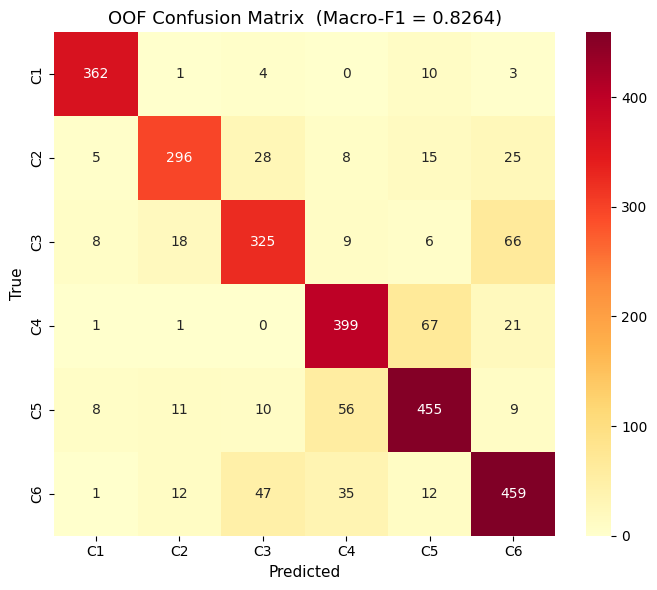

Saved → oof_confusion_matrix.png


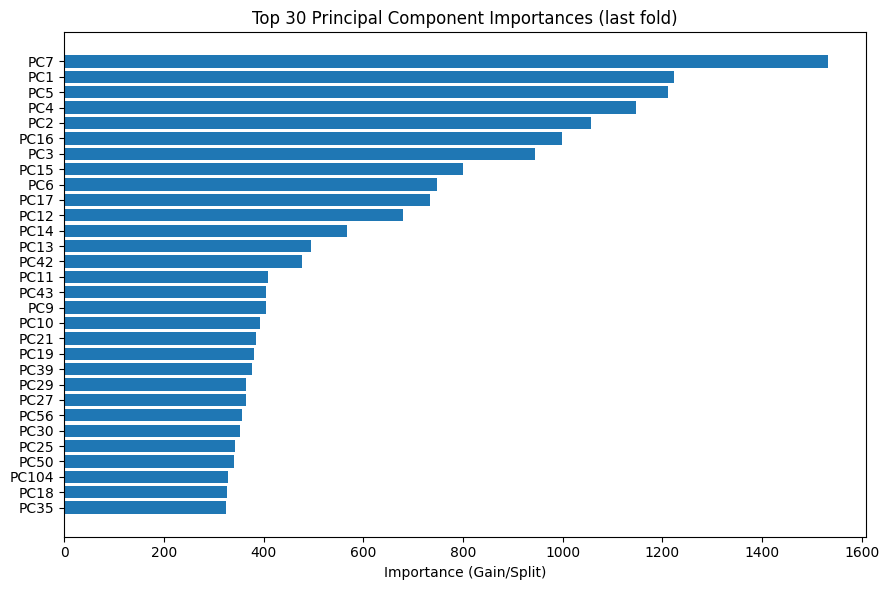

Saved → feature_importance.png


In [13]:
print("Per-class OOF report:\n")
print(classification_report(
    y, oof_labels,
    target_names=[f'Class {i+1}' for i in range(N_CLASSES)]
))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y, oof_labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'C{i+1}' for i in range(N_CLASSES)],
            yticklabels=[f'C{i+1}' for i in range(N_CLASSES)], ax=ax)
ax.set_title(f'OOF Confusion Matrix  (Macro-F1 = {oof_f1:.4f})', fontsize=13)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
plt.tight_layout()
plt.savefig('oof_confusion_matrix.png', dpi=120)
plt.show()
print("Saved → oof_confusion_matrix.png")


pca_feat_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
imp_df = (
    pd.DataFrame({'feature': pca_feat_names, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(30)
)
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.barh(imp_df['feature'][::-1], imp_df['importance'][::-1])
ax2.set_title('Top 30 Principal Component Importances (last fold)')
ax2.set_xlabel('Importance (Gain/Split)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print("Saved → feature_importance.png")

##  Cell 11 — Generate submission,csv file



In [ ]:
# Convert from 0-indexed back to 1-indexed
test_pred_labels = np.argmax(tst_proba, axis=1) + 1


submission = pd.DataFrame({
    SAMPLE_COL : test_feats[SAMPLE_COL].values,
    PRED_COL   : test_pred_labels,
})


submission[SAMPLE_COL] = submission[SAMPLE_COL].astype(int)

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\u2705 submission.csv saved ({len(submission)} rows)")
print(f"   Path: {os.path.abspath(submission_path)}")

print(f"\nPredicted class distribution:")
print(submission[PRED_COL].value_counts().sort_index().to_string())

print(f"\nPreview:")
print(submission.head(10).to_string(index=False))

# Trigger browser download on Colab
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(submission_path)

✅ submission.csv saved (1438 rows)
   Path: /content/submission.csv

Predicted class distribution:
Predicted_Class
1    186
2    141
3    198
4    274
5    370
6    269

Preview:
 Sample_ID  Predicted_Class
      2915                6
      2807                2
      2491                2
      1277                4
      2219                5
      1745                3
      2432                2
      3348                4
      2893                6
      2183                3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>